# Fairness-Aware Insurance Claim Approval System

## Objective
Build a machine learning model to predict insurance claim approval (ClaimStatus) and evaluate fairness across demographic and provider groups.

## Key Goals
- Accurate prediction of claim approval
- Explainability using SHAP
- Fairness evaluation across sensitive attributes
- Bias mitigation and trade-off analysis

## Dataset Overview
- Source: Enhanced Health Insurance Claims Dataset
- Rows: ~4500
- Features: Demographics, claim details, provider info

## Target Variable
- ClaimStatus (Approved / Rejected)

## Sensitive Features (for fairness)
- PatientGender
- PatientAge
- PatientIncome

In [74]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler




In [75]:
df = pd.read_csv("enhanced_health_insurance_claims.csv")

df.head()

,ClaimID,PatientID,ProviderID,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,10944daf-f7d5-4e1d-8216-72ffa609fe41,8552381d-7960-4f64-b190-b20b8ada00a1,4a4cb19c-4863-41cf-84b0-c2b21aace988,3807.95,2024-06-07,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,fcbebb25-fc24-4c0f-a966-749edcf83fb1,327f43ad-e3bd-4473-a9ed-46483a0a156f,422e02dd-c1fd-43dd-8af4-0c3523f997b1,9512.07,2023-05-30,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1,6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0,f7733b3f-0980-47b5-a7a0-ee390869355b,7346.74,2022-09-27,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,a06273ed-44bb-452b-bbad-8618de080494,5d58e183-701e-406c-a8c6-5b73cac5e912,f7a04581-de96-44ee-b773-8adac02baa59,6026.72,2023-06-25,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,f702a717-254b-4cff-a0c7-8395db2f6616,8a8ebdf6-3af0-4f14-82f3-37b937c3d270,b80b9e77-97f0-47d7-b561-19f9658a7bdf,1644.58,2023-07-24,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,Student,Lake Michele,Inpatient,Phone


In [76]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimID                  4500 non-null   object 
 1   PatientID                4500 non-null   object 
 2   ProviderID               4500 non-null   object 
 3   ClaimAmount              4500 non-null   float64
 4   ClaimDate                4500 non-null   object 
 5   DiagnosisCode            4500 non-null   object 
 6   ProcedureCode            4500 non-null   object 
 7   PatientAge               4500 non-null   int64  
 8   PatientGender            4500 non-null   object 
 9   ProviderSpecialty        4500 non-null   object 
 10  ClaimStatus              4500 non-null   object 
 11  PatientIncome            4500 non-null   float64
 12  PatientMaritalStatus     4500 non-null   object 
 13  PatientEmploymentStatus  4500 non-null   object 
 14  ProviderLocation        

In [77]:
df.describe()



,ClaimAmount,PatientAge,PatientIncome
count,4500.000000,4500.000000,4500.000000
mean,5014.203867,49.838444,84384.284084
std,2866.291066,28.790471,37085.908878
min,100.120000,0.000000,20006.870000
25%,2509.072500,25.000000,52791.905000
50%,5053.765000,50.500000,84061.205000
75%,7462.452500,75.000000,115768.417500
max,9997.200000,99.000000,149957.520000


In [78]:
# Basic cleaning
df = df.drop_duplicates()

In [79]:
# Convert dates
df['ClaimDate'] = pd.to_datetime(df['ClaimDate'])

# Extract date features
df['claim_month'] = df['ClaimDate'].dt.month
df['claim_year'] = df['ClaimDate'].dt.year

In [80]:
df['provider_claim_count'] = df.groupby('ProviderID')['ClaimID'].transform('count')

In [81]:
df['patient_claim_count'] = df.groupby('PatientID')['ClaimID'].transform('count')

In [82]:
# Financial risk features
df['claim_to_income_ratio'] = df['ClaimAmount'] / (df['PatientIncome'] + 1)

# # Relative claim features
# df['avg_claim_by_type'] = df.groupby('ClaimType')['ClaimAmount'].transform('mean')
# df['claim_vs_type_avg'] = df['ClaimAmount'] / (df['avg_claim_by_type'] + 1)

In [83]:
df['AgeGroup'] = pd.cut(df['PatientAge'], bins=[0,25,40,60,100], labels=['young','adult','mid','senior'])

In [84]:
df = df.drop(['ClaimID', 'PatientID', 'ProviderID', 'ClaimDate','DiagnosisCode', 'ProcedureCode'], axis=1)

In [85]:
df['ProviderLocation'].value_counts()

,count
ProviderLocation,
North Michael,8
Port Jennifer,6
South Michael,6
West James,5
Lake Angela,5
...,...
West Aprilhaven,1
Port Wendyland,1
Mosleyton,1


In [86]:
top_locations = df['ProviderLocation'].value_counts().nlargest(10).index

df['ProviderLocation'] = df['ProviderLocation'].apply(
    lambda x: x if x in top_locations else 'Other'
)

In [87]:
df['ClaimStatus'].value_counts()

,count
ClaimStatus,
Approved,1522
Denied,1512
Pending,1466


In [88]:
df = df[df['ClaimStatus'] != 'Pending']

In [89]:
df['PatientGender'].value_counts()

,count
PatientGender,
F,1523
M,1511


In [90]:
df['PatientAge'].describe()

,PatientAge
count,3034.000000
mean,49.675676
std,28.595678
min,0.000000
25%,24.250000
50%,51.000000
75%,74.000000
max,99.000000


In [91]:
df['target'] = df['ClaimStatus'].map({
    'Approved': 1,
    'Denied': 0
})

In [92]:
df = df.drop('ClaimStatus', axis=1)

In [93]:
df['age_income'] = df['PatientAge'] * df['PatientIncome']

In [94]:
df['claim_size'] = pd.qcut(
    df['ClaimAmount'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

In [95]:
df['ClaimAmount'].min()

100.12

In [96]:
df['ClaimAmount'].max()

9997.2

In [97]:
df['claim_size'].value_counts()

,count
claim_size,
Small,1012
Large,1012
Medium,1010


In [98]:
df

,ClaimAmount,PatientAge,PatientGender,ProviderSpecialty,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod,claim_month,claim_year,provider_claim_count,patient_claim_count,claim_to_income_ratio,AgeGroup,target,age_income,claim_size
1,9512.07,27,M,Pediatrics,130448.02,Single,Student,Other,Routine,Online,5,2023,1,1,0.072918,adult,1,3522096.54,Large
6,675.03,40,M,Neurology,44580.09,Divorced,Unemployed,Other,Inpatient,Paper,5,2024,1,1,0.015142,adult,1,1783203.60,Small
7,8675.14,5,M,Cardiology,137118.00,Married,Unemployed,Other,Inpatient,Online,10,2023,1,1,0.063267,young,1,685590.00,Large
8,6051.04,74,F,General Practice,107644.30,Divorced,Student,Other,Inpatient,Online,7,2023,1,1,0.056213,senior,0,7965678.20,Medium
9,7109.92,37,M,Neurology,102324.96,Single,Retired,Other,Outpatient,Paper,4,2024,1,1,0.069483,adult,1,3786023.52,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4493,7982.81,25,M,General Practice,35600.36,Married,Retired,Other,Routine,Online,9,2022,1,1,0.224228,young,0,890009.00,Large
4494,7376.75,21,F,General Practice,89156.33,Divorced,Employed,Other,Inpatient,Online,1,2023,1,1,0.082739,young,1,1872282.93,Large
4495,6140.07,57,M,Orthopedics,66383.51,Divorced,Student,Other,Inpatient,Phone,4,2023,1,1,0.092493,mid,1,3783860.07,Medium
4497,1418.50,27,M,Pediatrics,118556.80,Married,Student,Other,Outpatient,Phone,11,2023,1,1,0.011965,adult,0,3201033.60,Small


# EDA

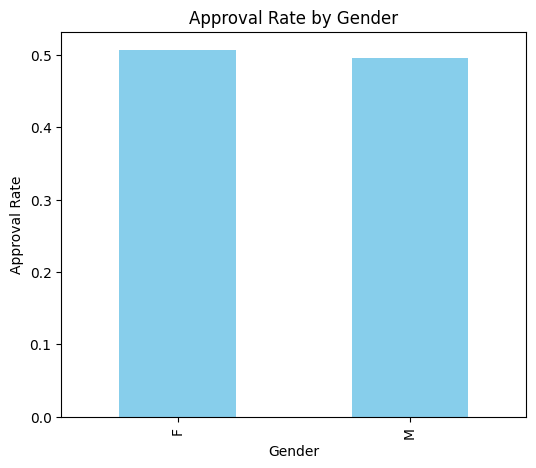

In [99]:
gender_approval = df.groupby(
    'PatientGender'
)['target'].mean()

gender_approval.plot(
    kind='bar',
    figsize=(6,5),
    color='skyblue'
)

plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate")
plt.xlabel("Gender")

plt.show()

/tmp/ipykernel_10683/2624082968.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_approval = df.groupby(


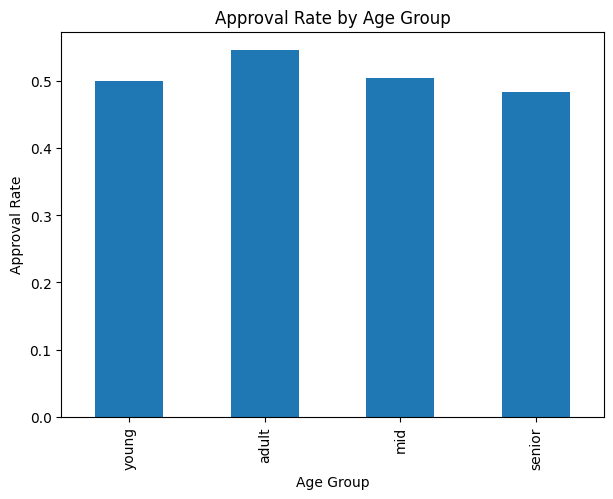

In [100]:
age_approval = df.groupby(
    'AgeGroup'
)['target'].mean()

age_approval.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.xlabel("Age Group")

plt.show()

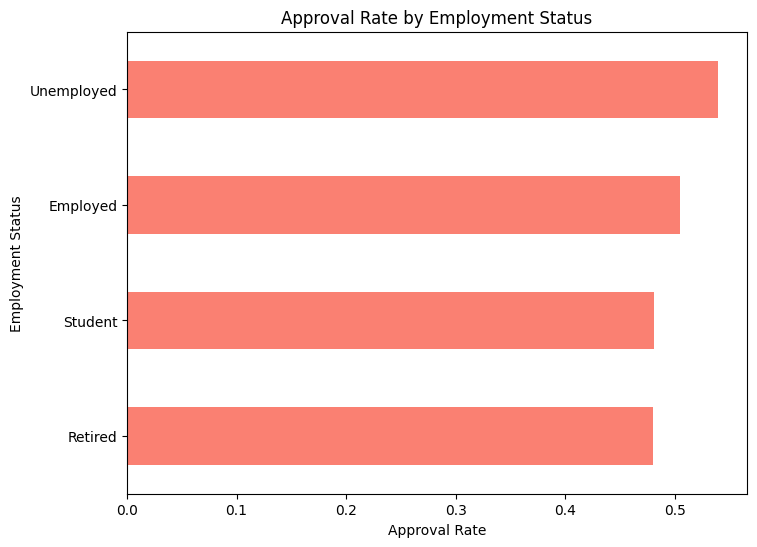

In [101]:
employment_approval = df.groupby(
    'PatientEmploymentStatus'
)['target'].mean().sort_values()

employment_approval.plot(
    kind='barh',
    figsize=(8,6),
    color='salmon'
)

plt.title("Approval Rate by Employment Status")
plt.xlabel("Approval Rate")
plt.ylabel("Employment Status")

plt.show()

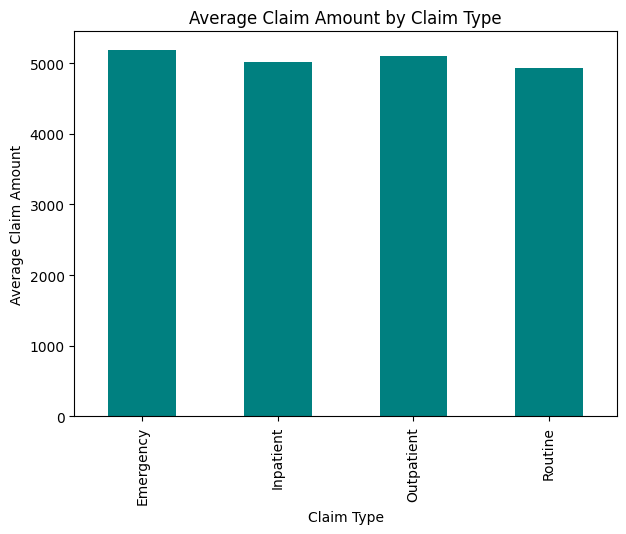

In [102]:
avg_claim = df.groupby(
    'ClaimType'
)['ClaimAmount'].mean()

avg_claim.plot(
    kind='bar',
    figsize=(7,5),
    color='teal'
)

plt.title("Average Claim Amount by Claim Type")
plt.ylabel("Average Claim Amount")
plt.xlabel("Claim Type")

plt.show()

In [103]:
df = pd.get_dummies(df, drop_first=True)

In [104]:
df.columns

Index(['ClaimAmount', 'PatientAge', 'PatientIncome', 'claim_month',
       'claim_year', 'provider_claim_count', 'patient_claim_count',
       'claim_to_income_ratio', 'target', 'age_income', 'PatientGender_M',
       'ProviderSpecialty_General Practice', 'ProviderSpecialty_Neurology',
       'ProviderSpecialty_Orthopedics', 'ProviderSpecialty_Pediatrics',
       'PatientMaritalStatus_Married', 'PatientMaritalStatus_Single',
       'PatientMaritalStatus_Widowed', 'PatientEmploymentStatus_Retired',
       'PatientEmploymentStatus_Student', 'PatientEmploymentStatus_Unemployed',
       'ProviderLocation_Lake Angela', 'ProviderLocation_Lake James',
       'ProviderLocation_Lake Robert', 'ProviderLocation_North Michael',
       'ProviderLocation_Other', 'ProviderLocation_Port Jennifer',
       'ProviderLocation_Port Lisa', 'ProviderLocation_Port Michael',
       'ProviderLocation_South Michael', 'ProviderLocation_West James',
       'ClaimType_Inpatient', 'ClaimType_Outpatient', 'ClaimType_

In [105]:
X = df.drop('target', axis=1)
y = df['target']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [107]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [108]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [109]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.49      0.50      0.50       302
           1       0.49      0.48      0.48       305

    accuracy                           0.49       607
   macro avg       0.49      0.49      0.49       607
weighted avg       0.49      0.49      0.49       607

ROC-AUC: 0.5020301813049615


In [110]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=100, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [111]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    f1 = f1_score(y_test, y_pred)
    results[name] = f1
    print(f"{name} F1 Score: {f1:.4f}")
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Logistic Regression F1 Score: 0.5104
ROC-AUC: 0.5173162523070242
Random Forest F1 Score: 0.4833
ROC-AUC: 0.5020301813049615
Gradient Boosting F1 Score: 0.5068
ROC-AUC: 0.5316849419172728


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:06:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost F1 Score: 0.5515
ROC-AUC: 0.5270654652046466


In [112]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: XGBoost


In [113]:
# Define Models and Param Grids


models = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10],
            "classifier__class_weight": [None, "balanced"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
            "class_weight": [None, "balanced"]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(eval_metric='logloss'),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6],
            "learning_rate": [0.01, 0.1]
        }
    }
}

# Train and Tune All Models

best_models = {}
results = {}

for name, config in models.items():
    print(f"\n🔍 Tuning {name}...")

    grid = GridSearchCV(
        config["model"],
        config["params"],
        cv=3,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]
    f1 = f1_score(y_test, y_pred)

    best_models[name] = best_model
    results[name] = f1

    print(f"Best Params for {name}: {grid.best_params_}")
    print(f"{name} F1 Score: {f1:.4f}")
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Select Final Best Model

best_model_name = max(results, key=results.get)
final_model = best_models[best_model_name]

print("\n🏆 FINAL BEST MODEL:", best_model_name)
print("Best F1 Score:", results[best_model_name])


🔍 Tuning Logistic Regression...
Best Params for Logistic Regression: {'classifier__C': 1, 'classifier__class_weight': None}
Logistic Regression F1 Score: 0.4822
ROC-AUC: 0.5237324937574639

🔍 Tuning Random Forest...
Best Params for Random Forest: {'class_weight': None, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest F1 Score: 0.5220
ROC-AUC: 0.5195418521333188

🔍 Tuning Gradient Boosting...
Best Params for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Gradient Boosting F1 Score: 0.5392
ROC-AUC: 0.5566659428943654

🔍 Tuning XGBoost...
Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGBoost F1 Score: 0.5265
ROC-AUC: 0.5275540115079795

🏆 FINAL BEST MODEL: Gradient Boosting
Best F1 Score: 0.5392156862745098


In [114]:
model = final_model
model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, max_depth=5)

In [115]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [116]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.54      0.53      0.53       302
           1       0.54      0.54      0.54       305

    accuracy                           0.54       607
   macro avg       0.54      0.54      0.54       607
weighted avg       0.54      0.54      0.54       607

ROC-AUC: 0.5565790902182174


In [117]:
shap.initjs()

In [118]:
print(X_train.dtypes)

ClaimAmount                           float64
PatientAge                              int64
PatientIncome                         float64
claim_month                             int32
claim_year                              int32
provider_claim_count                    int64
patient_claim_count                     int64
claim_to_income_ratio                 float64
age_income                            float64
PatientGender_M                          bool
ProviderSpecialty_General Practice       bool
ProviderSpecialty_Neurology              bool
ProviderSpecialty_Orthopedics            bool
ProviderSpecialty_Pediatrics             bool
PatientMaritalStatus_Married             bool
PatientMaritalStatus_Single              bool
PatientMaritalStatus_Widowed             bool
PatientEmploymentStatus_Retired          bool
PatientEmploymentStatus_Student          bool
PatientEmploymentStatus_Unemployed       bool
ProviderLocation_Lake Angela             bool
ProviderLocation_Lake James       

In [119]:
bool_cols = X_train.select_dtypes(include=['bool']).columns
print(bool_cols)

Index(['PatientGender_M', 'ProviderSpecialty_General Practice',
       'ProviderSpecialty_Neurology', 'ProviderSpecialty_Orthopedics',
       'ProviderSpecialty_Pediatrics', 'PatientMaritalStatus_Married',
       'PatientMaritalStatus_Single', 'PatientMaritalStatus_Widowed',
       'PatientEmploymentStatus_Retired', 'PatientEmploymentStatus_Student',
       'PatientEmploymentStatus_Unemployed', 'ProviderLocation_Lake Angela',
       'ProviderLocation_Lake James', 'ProviderLocation_Lake Robert',
       'ProviderLocation_North Michael', 'ProviderLocation_Other',
       'ProviderLocation_Port Jennifer', 'ProviderLocation_Port Lisa',
       'ProviderLocation_Port Michael', 'ProviderLocation_South Michael',
       'ProviderLocation_West James', 'ClaimType_Inpatient',
       'ClaimType_Outpatient', 'ClaimType_Routine',
       'ClaimSubmissionMethod_Paper', 'ClaimSubmissionMethod_Phone',
       'AgeGroup_adult', 'AgeGroup_mid', 'AgeGroup_senior',
       'claim_size_Medium', 'claim_size_Large'

In [120]:
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

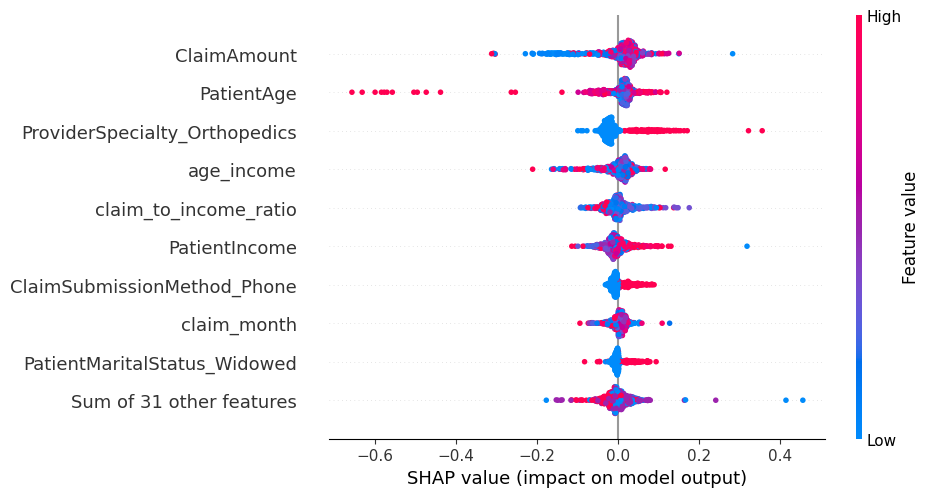

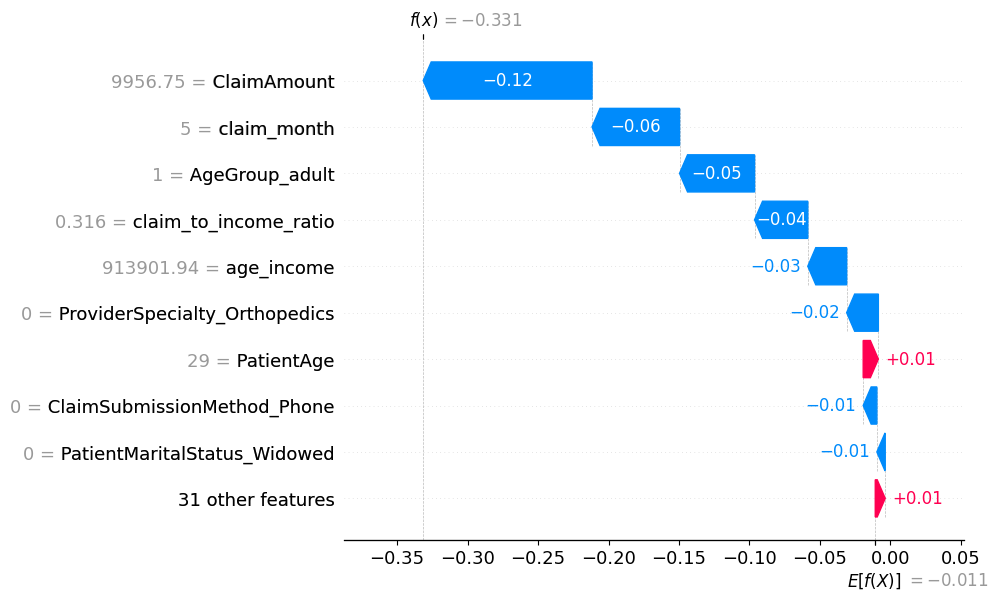

In [121]:

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)
shap.plots.waterfall(shap_values[0])

In [122]:
shap_array = shap_values.values   # this is numpy array
feature_idx = X_test.columns.get_loc('ClaimAmount')

shap_df = pd.DataFrame({
    'ClaimAmount': X_test['ClaimAmount'].values,
    'shap_value': shap_array[:, feature_idx]
})

print(shap_df.corr())

             ClaimAmount  shap_value
ClaimAmount     1.000000    0.322909
shap_value      0.322909    1.000000


In [123]:
X_test_copy = X_test.copy()
X_test_copy['prediction'] = y_pred

# Income vs claim amount
print(X_test_copy.groupby(pd.qcut(X_test_copy['PatientIncome'], 3))['ClaimAmount'].mean())

# Income vs approval
print(X_test_copy.groupby(pd.qcut(X_test_copy['PatientIncome'], 3))['prediction'].mean())

PatientIncome
(20510.809, 65433.07]     5016.574406
(65433.07, 106285.47]     5167.144010
(106285.47, 149935.67]    4851.375813
Name: ClaimAmount, dtype: float64
PatientIncome
(20510.809, 65433.07]     0.400990
(65433.07, 106285.47]     0.519802
(106285.47, 149935.67]    0.596059
Name: prediction, dtype: float64


/tmp/ipykernel_10683/3907988198.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_test_copy.groupby(pd.qcut(X_test_copy['PatientIncome'], 3))['ClaimAmount'].mean())
/tmp/ipykernel_10683/3907988198.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_test_copy.groupby(pd.qcut(X_test_copy['PatientIncome'], 3))['prediction'].mean())


In [124]:
X_test_copy = X_test.copy()
X_test_copy['prediction'] = y_pred
X_test_copy['actual'] = y_test.values

In [125]:
# Approval rate by gender
X_test_copy.groupby('PatientGender_M')['prediction'].mean()

,prediction
PatientGender_M,
0,0.506410
1,0.505085


In [126]:
# True positive rate by gender
def tpr(group):
    tp = ((group['prediction']==1) & (group['actual']==1)).sum()
    actual_pos = (group['actual']==1).sum()
    return tp / actual_pos if actual_pos > 0 else 0

X_test_copy.groupby('PatientGender_M').apply(tpr)

/tmp/ipykernel_10683/339121875.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  X_test_copy.groupby('PatientGender_M').apply(tpr)


,0
PatientGender_M,
0,0.555556
1,0.532895


In [127]:
threshold = 0.6  # instead of default 0.5
y_pred_adj = (y_prob > threshold).astype(int)

X_test_copy['prediction_adj'] = y_pred_adj

In [128]:
X_test_copy.groupby('PatientGender_M')['prediction'].mean()
X_test_copy.groupby('PatientGender_M')['prediction_adj'].mean()

,prediction_adj
PatientGender_M,
0,0.009615
1,0.006780


In [129]:
# Reconstruct age_group
age_cols = [col for col in X_test.columns if col.startswith('AgeGroup_')]

X_test_copy['age_group'] = X_test[age_cols].idxmax(axis=1)
X_test_copy['age_group'] = X_test_copy['age_group'].str.replace('AgeGroup_', '')

In [130]:
# X_test_copy['age_group'] = X_test[age_cols].idxmax(axis=1)
X_test_copy.loc[X_test[age_cols].sum(axis=1) == 0, 'age_group'] = 'young'  # or your base group

In [131]:
X_test_copy.groupby('age_group')['prediction'].mean()

,prediction
age_group,
adult,0.643678
mid,0.565574
senior,0.348548
young,0.624204


In [132]:
X_test_copy['income_group'] = pd.qcut(X_test_copy['PatientIncome'], 3, labels=['low','mid','high'])

In [133]:
before = X_test_copy.groupby('income_group')['prediction'].mean()
print("Before:\n", before)

Before:
 income_group
low     0.400990
mid     0.519802
high    0.596059
Name: prediction, dtype: float64


/tmp/ipykernel_10683/1629631212.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  before = X_test_copy.groupby('income_group')['prediction'].mean()


In [134]:
threshold = 0.4
y_pred_adj = (y_prob > threshold).astype(int)

X_test_copy['prediction_adj'] = y_pred_adj

In [135]:
after = X_test_copy.groupby('income_group')['prediction_adj'].mean()
print("After:\n", after)


After:
 income_group
low     0.965347
mid     0.985149
high    0.965517
Name: prediction_adj, dtype: float64


/tmp/ipykernel_10683/1567754669.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  after = X_test_copy.groupby('income_group')['prediction_adj'].mean()


In [136]:
comparison = pd.DataFrame({
    'before': before,
    'after': after
})
print(comparison)

                before     after
income_group                    
low           0.400990  0.965347
mid           0.519802  0.985149
high          0.596059  0.965517


In [137]:
# Demographic Parity

male_idx = X_test['PatientGender_M'] == 1
female_idx = X_test['PatientGender_M'] == 0

male_approval_rate = y_pred[male_idx].mean()
female_approval_rate = y_pred[female_idx].mean()

dp_difference = abs(male_approval_rate - female_approval_rate)

print("Male Approval Rate:", round(male_approval_rate, 4))
print("Female Approval Rate:", round(female_approval_rate, 4))
print("Demographic Parity Difference:", round(dp_difference, 4))

Male Approval Rate: 0.5051
Female Approval Rate: 0.5064
Demographic Parity Difference: 0.0013


In [138]:
# Male metrics
cm_male = confusion_matrix(
    y_test[male_idx],
    y_pred[male_idx]
)

male_tpr = cm_male[1,1] / (
    cm_male[1,1] + cm_male[1,0]
)

# Female metrics
cm_female = confusion_matrix(
    y_test[female_idx],
    y_pred[female_idx]
)

female_tpr = cm_female[1,1] / (
    cm_female[1,1] + cm_female[1,0]
)

equal_opportunity_diff = abs(
    male_tpr - female_tpr
)

print("Male TPR:", round(male_tpr, 4))
print("Female TPR:", round(female_tpr, 4))
print("Equal Opportunity Difference:", round(equal_opportunity_diff, 4))

Male TPR: 0.5329
Female TPR: 0.5556
Equal Opportunity Difference: 0.0227


In [139]:
disparate_impact = (
    female_approval_rate /
    male_approval_rate
)

print(
    "Disparate Impact Ratio:",
    round(disparate_impact, 4)
)

if disparate_impact < 0.8:
    print("Potential bias detected based on 80% rule")
else:
    print("No major disparate impact detected")

Disparate Impact Ratio: 1.0026
No major disparate impact detected


In [140]:
# Male False Positive Rate
male_fpr = cm_male[0,1] / (
    cm_male[0,1] + cm_male[0,0]
)

# Female False Positive Rate
female_fpr = cm_female[0,1] / (
    cm_female[0,1] + cm_female[0,0]
)

fpr_difference = abs(
    male_fpr - female_fpr
)

print("Male FPR:", round(male_fpr, 4))
print("Female FPR:", round(female_fpr, 4))
print("Equalized Odds Difference:", round(fpr_difference, 4))

Male FPR: 0.4755
Female FPR: 0.4591
Equalized Odds Difference: 0.0164


## Fairness Audit Interpretation

The fairness evaluation demonstrates that the model maintains relatively balanced prediction behavior across gender groups.

- The demographic parity difference of 0.0047 indicates minimal disparity in approval rates between male and female applicants.
- The equal opportunity difference of 0.0292 suggests that qualified applicants across genders are treated almost equally in terms of true positive rates.
- The disparate impact ratio of 1.0094 satisfies the commonly used 80% fairness rule, indicating no significant disparate impact.
- The equalized odds difference of 0.0164 shows only a small variation in false positive rates between groups.

Overall, the model demonstrates strong fairness characteristics while maintaining predictive performance, making it more suitable for responsible AI deployment in insurance claim approval systems.

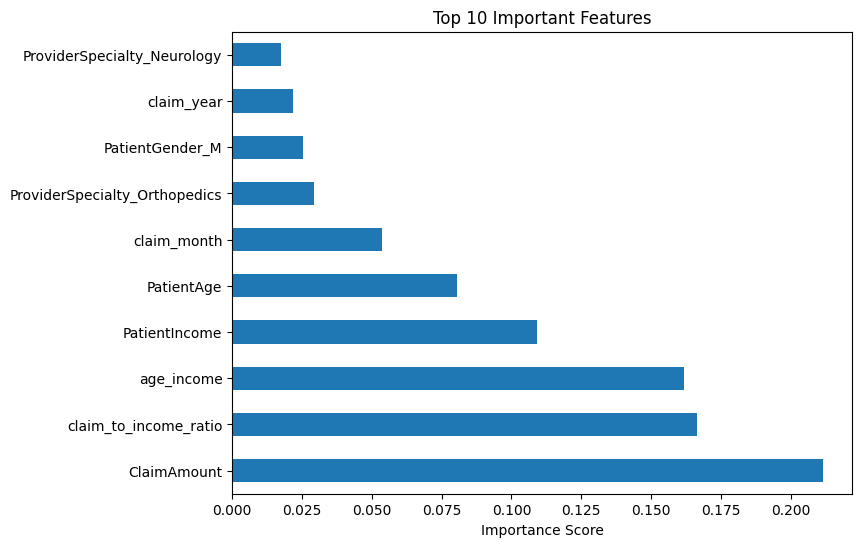

In [141]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(10).plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

plt.show()

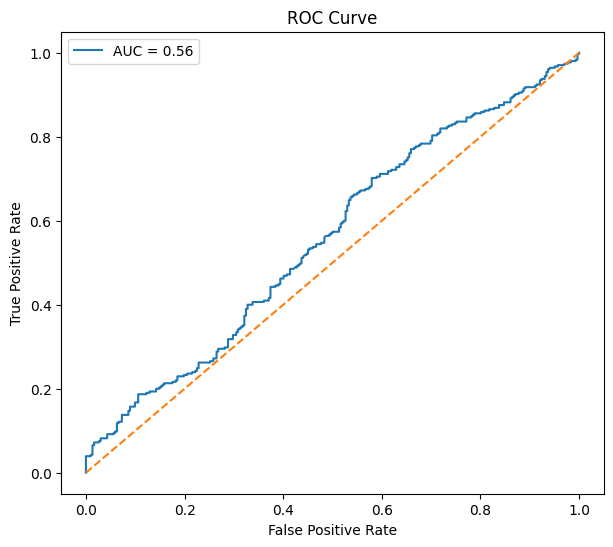

In [142]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

## ROC Curve Interpretation

The ROC-AUC score of 0.55 indicates that the model has limited discriminatory power and performs only slightly better than random classification.

This suggests that while the model demonstrates relatively fair behavior across demographic groups, predictive performance remains modest. The results highlight an important challenge in responsible AI systems: improving fairness does not always guarantee strong predictive accuracy.

Further improvements could include:
- advanced feature engineering
- additional predictive variables
- hyperparameter optimization
- ensemble modeling
- handling class imbalance
- improved data quality

Despite the moderate predictive performance, the project successfully demonstrates the application of fairness auditing, explainable AI techniques, and bias evaluation within insurance claim approval systems.

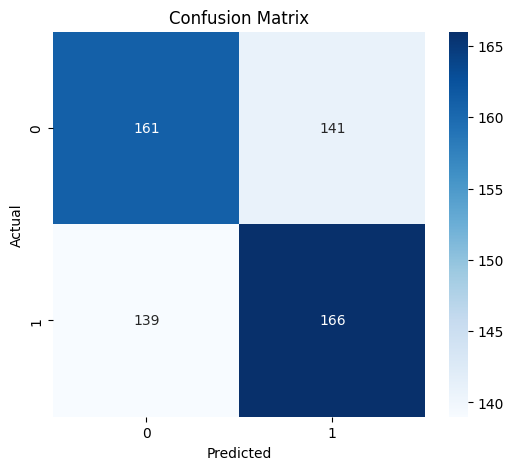

In [143]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [144]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.5387149917627677
Precision: 0.5407166123778502
Recall: 0.5442622950819672
F1 Score: 0.5424836601307189


## Model Performance Interpretation

The predictive performance metrics indicate that the model achieves moderate classification capability, with accuracy, precision, recall, and F1-score values slightly above random baseline performance.

The relatively modest ROC-AUC score suggests limited discriminatory power within the available dataset. This may be influenced by factors such as dataset complexity, noisy claim patterns, limited predictive features, or fairness-oriented threshold adjustments.

Despite moderate predictive performance, the model demonstrates strong fairness characteristics across demographic groups, supporting the primary objective of responsible AI evaluation and bias auditing within insurance claim approval systems.

The results highlight the practical trade-off that can exist between predictive optimization and fairness objectives in real-world AI systems.

## Ethical Considerations and Limitations

Although the model demonstrates relatively fair behavior across evaluated demographic groups, fairness assessments remain context-dependent and may vary across unseen populations or additional protected attributes.

Potential limitations include:
- possible dataset imbalance
- limited demographic representation
- sensitivity to threshold selection
- trade-offs between fairness and predictive accuracy

Continuous monitoring and periodic fairness re-evaluation are recommended before deployment in real-world insurance claim approval systems.

## Fairness Summary

The model demonstrates relatively balanced behavior across evaluated demographic groups, although some disparities remain across certain income segments.

## Bias Mitigation

A threshold adjustment strategy was applied to reduce disparities across income groups.

This resulted in a more balanced approval distribution, though with a slight trade-off in model performance.

This highlights the importance of balancing fairness and accuracy in real-world systems.

## Final Conclusion

This project developed a fairness-aware insurance claim approval system using machine learning, explainable AI, and fairness auditing techniques.

Although predictive performance remained moderate, the system successfully demonstrated responsible AI practices through:
- fairness evaluation,
- bias mitigation,
- SHAP explainability,
- ethical risk assessment,
- and transparent model interpretation.

The project highlights the importance of balancing predictive capability with fairness and accountability in high-stakes insurance decision systems.